Using the Local module
====================

In this notebook, we demonstrate how to use the pySCATMECH Local module. Local models are those that calculate the differential scattering cross section (DSC) of individual local defects or particles. The bidirectional reflectance distribution function (BRDF) is then determined from 
$$
f_\mathrm{r} = \frac{1}{\cos{\theta_\mathrm{i}}\cos{\theta_\mathrm{r}}}\frac{N}{A}\frac{\mathrm{d}\sigma}{\mathrm{d}\Omega},
$$
where $\mathrm{d}\sigma/\mathrm{d}\Omega$ is the differential scattering cross section, $N/A$ is the number of the defects or particles per unit area, $\theta_\mathrm{i}$ is the incident polar angle, and $\theta_\mathrm{r}$ is the reflected polar angle. Local_BRDF_Model provides this conversion to its inherited classes.

In this notebook, we will demonstrate the use of the Local package to calculate the DCS.

First, import the necessary libraries. We will be using <tt>matplotlib.pyplot</tt> for graphing.

In [1]:
import matplotlib.pyplot as plt
from pySCATMECH.local import *

The key class in the BRDF module is the `Local_BRDF_Model`.  Let's create a `Local_BRDF_Model` and give it some parameters:

In [2]:
spherecoat = {None : 'No_StackModel'}

stack = {None : 'No_StackModel'}

parameters = {'lambda' : 0.532,
              'substrate' : 4.06+0.05j,
              'type' : 0,
              'sphere' : 1.59,
              'radius' : 0.05,
              'spherecoat' : spherecoat,
              'stack' : stack,
              'delta' : 0,
              'lmax' : 0,
              'order' : -1,
              'Norm_Inc_Approx' : 0,
              'improve' : 3}

model = Local_BRDF_Model("Bobbert_Vlieger_BRDF_Model",parameters)
print(model)

{None : 'Bobbert_Vlieger_BRDF_Model',
'lambda' : '0.532',
'substrate' : '(4.06,0.05)',
'type' : '0',
'density' : '1',
'sphere' : '(1.59,0)',
'radius' : '0.05',
'spherecoat' : 'No_StackModel',
'stack' : 'No_StackModel',
'delta' : '0',
'lmax' : '0',
'order' : '-1',
'Norm_Inc_Approx' : '0',
'improve' : '3'}


In [3]:
# Needed to use OpticalFunction, Film, and FilmStack...
from pySCATMECH.fresnel import *

# Define two materials...
PS = OpticalFunction(lambda L: (1+1.4435*L**2/(L**2-0.020216))**(1/2), np.arange(0.4356,1.052,0.01))
SiO2 = OpticalFunction(lambda L:(1+0.6961663*L**2/(L**2-0.0684043**2)+
                                   0.4079426*L**2/(L**2-0.1162414**2)+
                                   0.8974794*L**2/(L**2-9.896161**2))**(1/2), 
                                    np.exp(np.linspace(math.log(0.210),math.log(6.7),50)))

Si = OpticalFunction('silicon')

# Define the stack...
spherecoat =  FilmStack()
stack = FilmStack([Film(SiO2,thickness =0.0017)])

parameters = {'lambda' : 0.305,
              'substrate' : Si,
              'type' : 0,
              'sphere' : PS,
              'radius' : 0.05,
              'spherecoat' : spherecoat,
              'stack' : stack,
              'delta' : 0,
              'lmax' : 0,
              'order' : -1,
              'Norm_Inc_Approx' : 0,
              'improve' : 3}

model.setParameters(parameters)
print(model)

{None : 'Bobbert_Vlieger_BRDF_Model',
'lambda' : '0.305',
'substrate' : 'silicon',
'type' : '0',
'density' : '1',
'sphere' : 'vxJvQ4IPbrxq.tmp',
'radius' : '0.05',
'spherecoat' : {None : 'Stack_StackModel',
                 'stack' : '(empty)'},
'stack' : {None : 'Stack_StackModel',
            'stack' : 'RE5o5yZbsJp7.tmp 0.0017'},
'delta' : '0',
'lmax' : '0',
'order' : '-1',
'Norm_Inc_Approx' : '0',
'improve' : '3'}


Let's evaluate the Mueller matrix scattering cross section:

In [4]:
mDSC = model.MuellerDSC(60*deg, 30*deg)
print(mDSC)

[[ 1.19555904e-03  3.03609177e-04  1.51343629e-20 -1.43567684e-21]
 [ 3.03609177e-04  1.19555904e-03  9.24471105e-21  7.73927323e-21]
 [-1.36519115e-20  3.84407409e-21 -1.13418331e-03  2.25413141e-04]
 [ 8.71843659e-22  9.30638582e-21 -2.25413141e-04 -1.13418331e-03]]


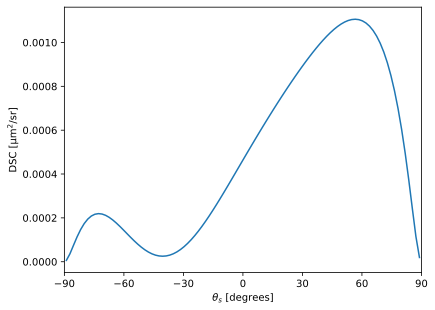

In [5]:
thetaslist = np.linspace(-89, 89, 100)
DSClist = [model.DSC(60*deg, thetas*deg, inc=Polarization('p'), sens=Sensitivity('u')) for thetas in thetaslist]

plt.plot(thetaslist,DSClist)
plt.xlabel(r"$\theta_s$ [degrees]")
plt.ylabel(r"DSC [$\mathrm{\mu m}^2/\mathrm{sr}$]")
plt.xlim((-90,90))
plt.xticks(np.linspace(-90,90,7))
plt.show()

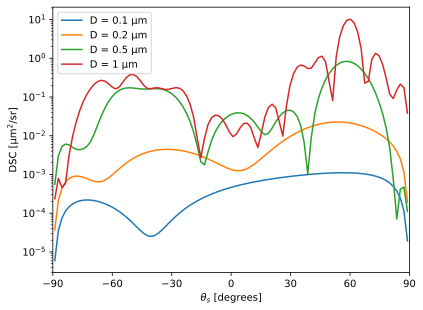

In [6]:
thetaslist = np.linspace(-89, 89, 100)

plt.figure()
for D in [0.1, 0.2, 0.5, 1.0]:
    parameters["radius"] = D/2
    model.setParameters(parameters)
    DSClist = [model.DSC(60*deg, thetas*deg, inc=Polarization('p'), sens=Sensitivity('u')) for thetas in thetaslist]
    plt.plot(thetaslist, DSClist, label = "D = %g µm" % D)

plt.xlabel(r"$\theta_s$ [degrees]")
plt.ylabel(r"DSC [$\mathrm{\mu m}^2/\mathrm{sr}$]")
plt.xlim((-90,90))
plt.yscale('log')
plt.xticks(np.linspace(-90,90,7))
plt.legend()
plt.show()